# 🛒 SmartShop AI Engine
## Phase 1 — EDA + Machine Learning (Random Forest vs SVM)
**Dataset:** UCI Online Shoppers Purchasing Intention Dataset  
**Goal:** Predict cart abandonment (churn) with maximum **Precision**

---
## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

print('✅ All libraries imported successfully!')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

✅ All libraries imported successfully!
Pandas: 3.0.2 | NumPy: 2.4.4


---
## Cell 2 — Load Dataset
> **Download the dataset first:**  
> Go to: https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset  
> Download the CSV and place it in the `data/` folder as `online_shoppers_intention.csv`

In [2]:
# Load dataset
df = pd.read_csv('../data/online_shoppers_intention.csv')

print('📊 Dataset Shape:', df.shape)
print('\n📋 Columns:')
print(df.columns.tolist())
print('\n🔍 First 5 rows:')
df.head()

📊 Dataset Shape: (12330, 18)

📋 Columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

🔍 First 5 rows:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


---
## Cell 3 — Basic Info & Null Check

In [3]:
print('📌 Data Types & Non-Null Counts:')
print(df.info())

print('\n❓ Missing Values:')
print(df.isnull().sum())

print('\n🎯 Target Distribution (Revenue):')
print(df['Revenue'].value_counts())
print(f"\nChurn Rate: {df['Revenue'].mean()*100:.1f}%")

📌 Data Types & Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  T

---
## Cell 4 — EDA Visualization 1: Class Imbalance Bar Chart

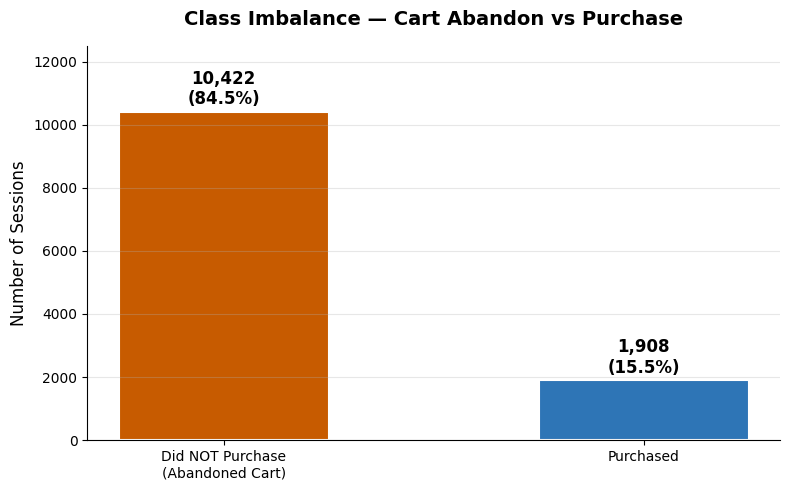


💡 Insight: Heavy class imbalance — 84.5% did NOT purchase.
   → We will use class_weight="balanced" in our models to handle this.


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

counts = df['Revenue'].value_counts()
labels = ['Did NOT Purchase\n(Abandoned Cart)', 'Purchased']
colors = ['#C75B00', '#2E75B6']

bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)

# Add value labels on bars
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}\n({count/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Class Imbalance — Cart Abandon vs Purchase', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Sessions', fontsize=12)
ax.set_ylim(0, max(counts.values) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/viz1_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: Heavy class imbalance — 84.5% did NOT purchase.')
print('   → We will use class_weight="balanced" in our models to handle this.')

---
## Cell 5 — EDA Visualization 2: Correlation Heatmap

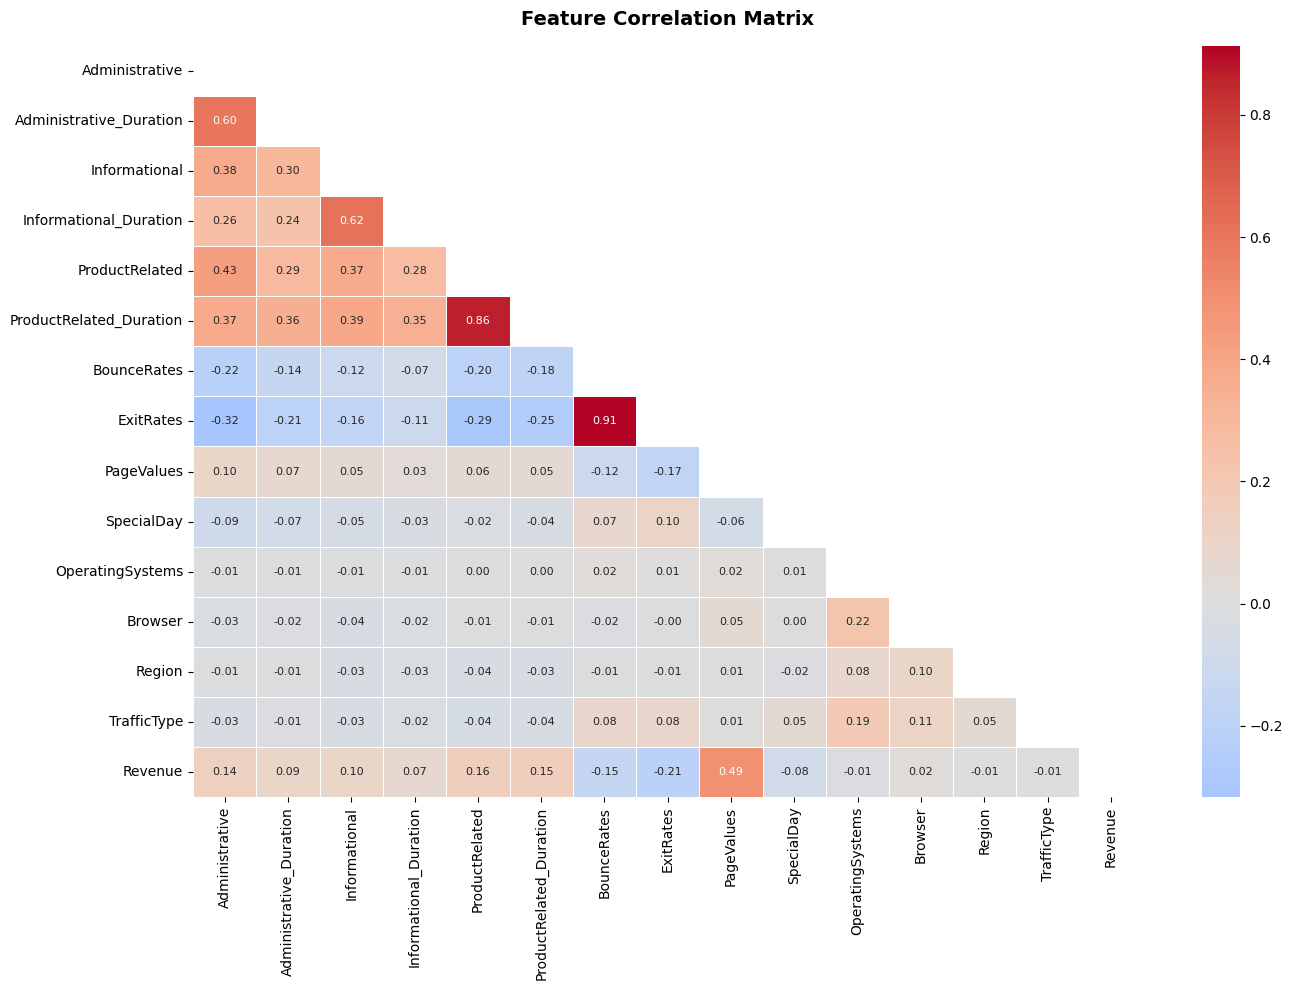


🔗 Top Features Correlated with Revenue (Purchase):
PageValues                 0.492569
ExitRates                  0.207071
ProductRelated             0.158538
ProductRelated_Duration    0.152373
BounceRates                0.150673
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Name: Revenue, dtype: float64

💡 Insight: PageValues and ProductRelated_Duration are strongest predictors.


In [5]:
fig, ax = plt.subplots(figsize=(14, 10))

# Encode Revenue as int for correlation
df_corr = df.copy()
df_corr['Revenue'] = df_corr['Revenue'].astype(int)
numeric_df = df_corr.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/viz2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlated with Revenue
rev_corr = corr_matrix['Revenue'].drop('Revenue').abs().sort_values(ascending=False)
print('\n🔗 Top Features Correlated with Revenue (Purchase):')
print(rev_corr.head(8))
print('\n💡 Insight: PageValues and ProductRelated_Duration are strongest predictors.')

---
## Cell 6 — EDA Visualization 3: Monthly Purchase Trend

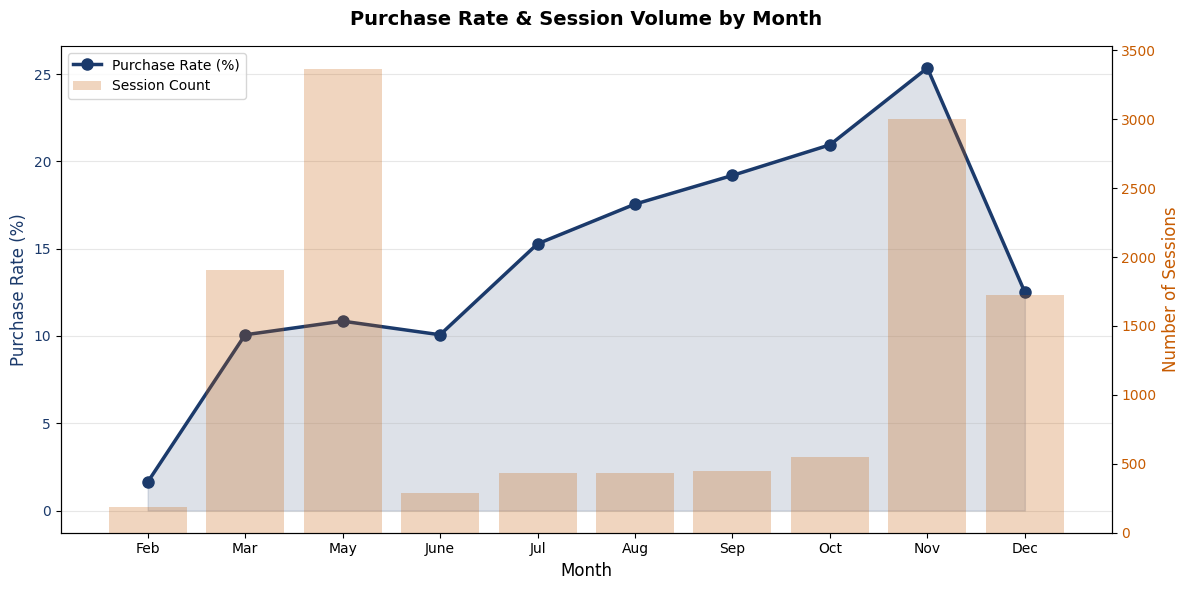


💡 Insight: November has the highest purchase rate (holiday season effect).
   → Most cart abandonment happens in low-traffic months (Feb, Mar).


In [6]:
month_order = ['Jan','Feb','Mar','Apr','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
month_data = df.groupby('Month')['Revenue'].agg(['mean', 'count']).reindex(
    [m for m in month_order if m in df['Month'].unique()]
)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Purchase rate line
color1 = '#1B3A6B'
ax1.plot(month_data.index, month_data['mean'] * 100, 
         marker='o', color=color1, linewidth=2.5, markersize=8, label='Purchase Rate (%)')
ax1.fill_between(range(len(month_data)), month_data['mean'] * 100, alpha=0.15, color=color1)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Purchase Rate (%)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range(len(month_data)))
ax1.set_xticklabels(month_data.index)

# Session count bars
ax2 = ax1.twinx()
ax2.bar(range(len(month_data)), month_data['count'], alpha=0.25, color='#C75B00', label='Session Count')
ax2.set_ylabel('Number of Sessions', color='#C75B00', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#C75B00')

ax1.set_title('Purchase Rate & Session Volume by Month', fontsize=14, fontweight='bold', pad=15)
ax1.spines['top'].set_visible(False)
ax1.grid(axis='y', alpha=0.3)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../data/viz3_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: November has the highest purchase rate (holiday season effect).')
print('   → Most cart abandonment happens in low-traffic months (Feb, Mar).')

---
## Cell 7 — EDA Visualization 4: Bounce Rate vs Exit Rate (Churn Risk Scatter)

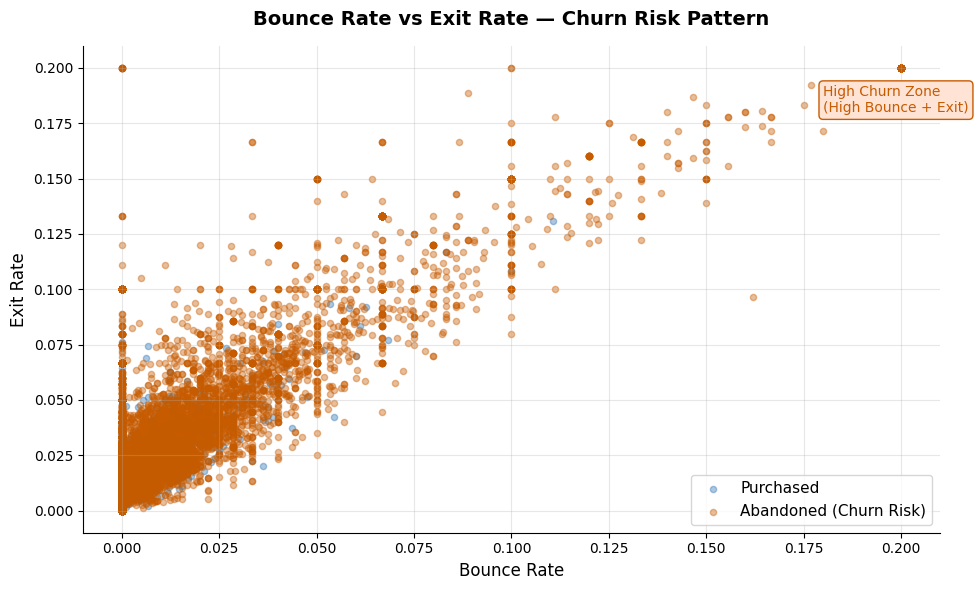


💡 Insight: Users with HIGH bounce + exit rates almost never complete purchase.
   → These are our primary churn risk targets for AI-generated emails.


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = df['Revenue'].map({True: '#2E75B6', False: '#C75B00'})
labels_map = {True: 'Purchased', False: 'Abandoned (Churn)'}

for revenue_val, color, label in [(True, '#2E75B6', 'Purchased'), 
                                   (False, '#C75B00', 'Abandoned (Churn Risk)')]:
    subset = df[df['Revenue'] == revenue_val]
    ax.scatter(subset['BounceRates'], subset['ExitRates'],
               c=color, alpha=0.4, s=20, label=label)

ax.set_xlabel('Bounce Rate', fontsize=12)
ax.set_ylabel('Exit Rate', fontsize=12)
ax.set_title('Bounce Rate vs Exit Rate — Churn Risk Pattern', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)

# Add annotation
ax.annotate('High Churn Zone\n(High Bounce + Exit)', 
             xy=(0.18, 0.18), fontsize=10, color='#C75B00',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFE4D6', edgecolor='#C75B00'))

plt.tight_layout()
plt.savefig('../data/viz4_bounce_exit_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: Users with HIGH bounce + exit rates almost never complete purchase.')
print('   → These are our primary churn risk targets for AI-generated emails.')

---
## Cell 8 — Data Preprocessing

In [8]:
df_model = df.copy()

# Encode categorical columns
le = LabelEncoder()
for col in ['Month', 'VisitorType']:
    df_model[col] = le.fit_transform(df_model[col])
    print(f'✅ Encoded: {col}')

# Convert booleans to int
df_model['Weekend'] = df_model['Weekend'].astype(int)
df_model['Revenue'] = df_model['Revenue'].astype(int)

# Features and target
X = df_model.drop('Revenue', axis=1)
y = df_model['Revenue']

print(f'\n📐 Feature Matrix Shape: {X.shape}')
print(f'🎯 Target Distribution: {dict(y.value_counts())}')

# Train/Test Split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\n✂️  Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

# Scale for SVM
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('\n✅ Preprocessing complete!')

✅ Encoded: Month
✅ Encoded: VisitorType

📐 Feature Matrix Shape: (12330, 17)
🎯 Target Distribution: {0: np.int64(10422), 1: np.int64(1908)}

✂️  Train size: 9864 | Test size: 2466

✅ Preprocessing complete!


---
## Cell 9 — Model 1: Random Forest + GridSearchCV
> ⏳ This may take 3–5 minutes due to GridSearchCV cross-validation

In [9]:
print('🌲 Training Random Forest with GridSearchCV...')
print('   Optimizing for: PRECISION (minimize wasted discounts)\n')

param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'   # handles class imbalance
)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    scoring='precision',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print(f'\n✅ Best Parameters: {grid_search.best_params_}')
print(f'   Best CV Precision: {grid_search.best_score_:.4f}')

🌲 Training Random Forest with GridSearchCV...
   Optimizing for: PRECISION (minimize wasted discounts)

Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
   Best CV Precision: 0.7517


---
## Cell 10 — Model 2: SVM (RBF Kernel)

In [10]:
print('⚙️  Training SVM (RBF Kernel)...')

svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm.fit(X_train_sc, y_train)

print('✅ SVM trained successfully!')

⚙️  Training SVM (RBF Kernel)...
✅ SVM trained successfully!


---
## Cell 11 — Model Evaluation & Comparison

In [11]:
# Predictions
rf_preds  = best_rf.predict(X_test)
svm_preds = svm.predict(X_test_sc)

rf_precision  = precision_score(y_test, rf_preds)
svm_precision = precision_score(y_test, svm_preds)

print('=' * 55)
print('          MODEL COMPARISON — PRECISION FOCUS')
print('=' * 55)

print(f'\n🌲 Random Forest Precision : {rf_precision:.4f} ({rf_precision*100:.1f}%)')
print(f'⚙️  SVM Precision           : {svm_precision:.4f} ({svm_precision*100:.1f}%)')

winner = 'Random Forest' if rf_precision >= svm_precision else 'SVM'
print(f'\n🏆 Winner: {winner}')

print('\n--- Random Forest Classification Report ---')
print(classification_report(y_test, rf_preds, target_names=['Safe', 'Churn Risk']))

print('--- SVM Classification Report ---')
print(classification_report(y_test, svm_preds, target_names=['Safe', 'Churn Risk']))

          MODEL COMPARISON — PRECISION FOCUS

🌲 Random Forest Precision : 0.7757 (77.6%)
⚙️  SVM Precision           : 0.5304 (53.0%)

🏆 Winner: Random Forest

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

        Safe       0.92      0.97      0.94      2084
  Churn Risk       0.78      0.53      0.63       382

    accuracy                           0.90      2466
   macro avg       0.85      0.75      0.79      2466
weighted avg       0.90      0.90      0.90      2466

--- SVM Classification Report ---
              precision    recall  f1-score   support

        Safe       0.94      0.89      0.91      2084
  Churn Risk       0.53      0.69      0.60       382

    accuracy                           0.86      2466
   macro avg       0.73      0.79      0.76      2466
weighted avg       0.88      0.86      0.86      2466



---
## Cell 12 — Confusion Matrix Visualization

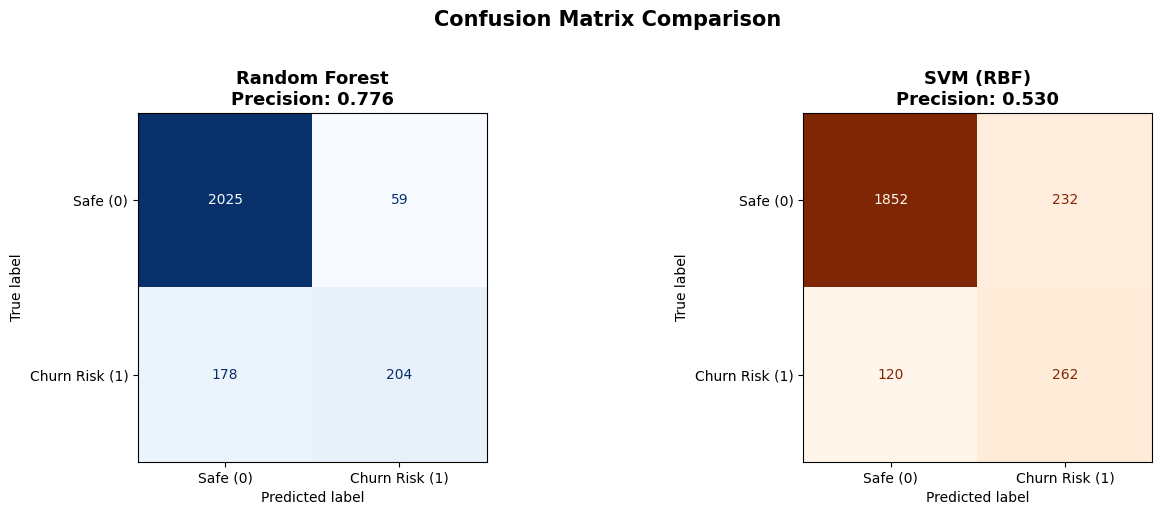


💡 Lower False Positives = Better Precision = Less wasted discounts!


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title, color in [
    (axes[0], rf_preds,  'Random Forest', 'Blues'),
    (axes[1], svm_preds, 'SVM (RBF)',     'Oranges')
]:
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['Safe (0)', 'Churn Risk (1)'])
    disp.plot(ax=ax, cmap=color, colorbar=False)
    ax.set_title(f'{title}\nPrecision: {precision_score(y_test, preds):.3f}', 
                  fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/viz5_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Lower False Positives = Better Precision = Less wasted discounts!')

---
## Cell 13 — Feature Importance (Random Forest)

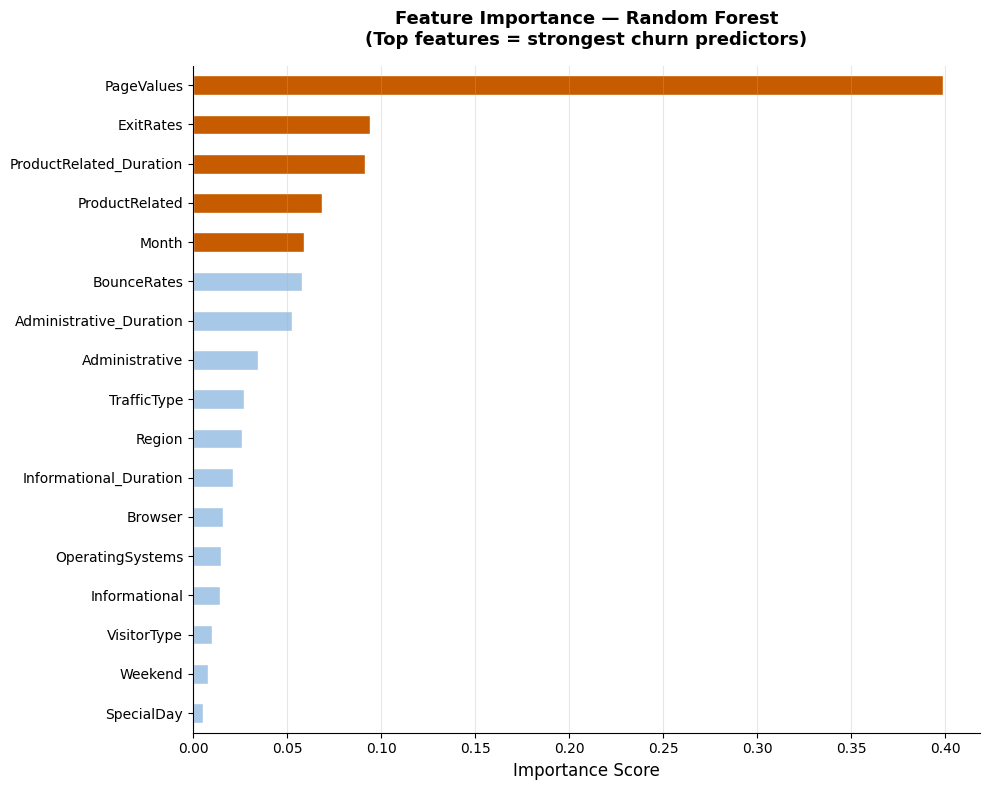


🔑 Top 5 Churn Predictors:
PageValues                 0.398541
ExitRates                  0.094165
ProductRelated_Duration    0.091455
ProductRelated             0.068441
Month                      0.058850
dtype: float64


In [13]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#C75B00' if i >= len(importances) - 5 else '#A8C8E8' 
               for i in range(len(importances))]

importances.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')

ax.set_title('Feature Importance — Random Forest\n(Top features = strongest churn predictors)', 
              fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/viz6_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🔑 Top 5 Churn Predictors:')
print(importances.tail(5).sort_values(ascending=False))

---
## Cell 14 — Save Winner Model + Scaler

In [14]:
# Save the winning model (Random Forest) and scaler
joblib.dump(best_rf, '../models/rf_model.pkl')
joblib.dump(scaler,  '../models/scaler.pkl')

print('💾 Models saved successfully!')
print('   → ../models/rf_model.pkl')
print('   → ../models/scaler.pkl')

# Verify by reloading
test_model  = joblib.load('../models/rf_model.pkl')
test_scaler = joblib.load('../models/scaler.pkl')

# Quick smoke test
sample = np.array([[8, 14.5, 3, 0.35, 0.45] + [0] * (X.shape[1] - 5)])
# Use first 5 features for quick demo
sample_full = X_test.iloc[[0]]
pred = test_model.predict(sample_full)
print(f'\n🧪 Smoke Test Prediction: {"🔴 CHURN RISK" if pred[0]==1 else "🟢 SAFE"}')
print('\n✅ Phase 1 Complete! Models are ready for FastAPI integration.')

💾 Models saved successfully!
   → ../models/rf_model.pkl
   → ../models/scaler.pkl

🧪 Smoke Test Prediction: 🟢 SAFE

✅ Phase 1 Complete! Models are ready for FastAPI integration.


---
## Cell 15 — Why Precision? (Written Defense)

### 📊 Metric Selection Rationale: Precision

In this SmartShop AI project, we chose **Precision** as our primary evaluation metric over Recall or F1-Score. Here is why:

**The Business Problem:**  
Our system sends a **10% discount email (SAVE10)** to users predicted as churn risks. Every prediction has a direct financial cost.

| Prediction Type | Real World Meaning | Business Impact |
|---|---|---|
| **True Positive** | Correctly identified a churner | ✅ Discount saves the sale — revenue recovered |
| **False Positive** | Gave discount to someone who would've bought anyway | ❌ **Direct revenue loss** — 10% discount wasted |
| **False Negative** | Missed a churner — no email sent | 😐 Sale lost, but no extra cost |
| **True Negative** | Correctly identified a safe user | ✅ No discount sent — full price paid |

**Why NOT Recall?**  
High Recall means "catch every churner" — but this causes many False Positives. Giving discounts to users who were already going to buy costs the company money on every legitimate purchase.

**Why NOT F1?**  
F1-Score balances Precision and Recall equally, but in our business case, **False Positives are more expensive than False Negatives**. The asymmetry of cost makes Precision the right choice.

**Conclusion:**  
By maximizing Precision, we ensure that when the system sends a discount email, it is almost always to a genuine churn risk. This protects profit margins while recovering real abandoned sales.

> **Formula:** Precision = TP / (TP + FP)  
> **Our Goal:** Minimize FP (wasted discounts), not just maximize correct predictions.